## Abstract

Content teams often need to prioritize which content items should be reviewed or improved when the number of available items is large. This study investigates whether historical search-performance signals and content-level characteristics can be used to rank content items according to their relative priority for review. Using the FlyRank internship warehouse dataset, the analysis combines daily search-performance data with content-level characteristics at the client-content level. A reference opportunity score is constructed from future search visibility, average position, and click-through rate, and a Random Forest regression model is trained using historical performance and content characteristics. Model performance is evaluated using a historical feature period and a subsequent future evaluation period, followed by a random 80/20 train-test split among eligible observations. Ranking performance is assessed using Precision@K, Recall@K, and NDCG@K, with simple historical-performance baselines used for comparison. The model achieved an NDCG of 0.983 at K=10 and 0.969 at K=100, compared with 0.750 and 0.807 respectively for the historical-impressions baseline. These results indicate that the model was more aligned with the constructed future opportunity benchmark than the tested simple baselines. However, the opportunity score is a constructed benchmark rather than a ground-truth measure of successful optimization, and the observational nature of the data does not support causal claims about changes in rankings or traffic. The resulting framework is therefore intended as a decision-support tool for prioritizing content review rather than as a guarantee of future SEO improvement.


# 1. Introduction

Digital content portfolios can contain a large number of articles and other content items, making it difficult for content teams to determine which items should be reviewed first. A simple review process based only on traffic, clicks, or search position may overlook important combinations of signals. For example, a content item may receive substantial search impressions while maintaining a weak average position and a low click-through rate. Such patterns can indicate that an item deserves further investigation, although they do not establish that a particular optimization action will improve its future performance.

This study focuses on the problem of prioritizing content items for review using observable historical data. Rather than attempting to predict a specific Google ranking outcome or claim a causal relationship between optimization and future performance, the analysis develops a data-driven ranking framework that combines historical search-performance signals with content-level characteristics.

## 1.1 Practical Decision

The practical decision addressed by this study is:

> Which content items should be prioritized for review or potential improvement?

A useful prioritization system should produce a ranked list of content items and provide interpretable evidence explaining why an item received a high priority score.

## 1.2 Research Question

The research question is:

> Can historical search performance and content-level characteristics be used to rank content items by their priority for review or improvement?

## 1.3 Motivation

When many content items are available for review, manually evaluating every item with the same level of attention is inefficient. A ranking framework can help allocate review effort toward items showing stronger combinations of observable opportunity signals.

The analysis therefore focuses on relative prioritization rather than guaranteed future outcomes. Historical impressions, clicks, average search position, click-through rate, search demand, competition, backlinks, and content characteristics are considered as potential signals for ranking content items.

## 1.4 Scope

The analysis uses the client-content pair as the primary analytical unit. Search-performance observations are aggregated over a historical feature period from June 1 to June 20, 2026, while the subsequent period from June 21 to June 30, 2026 is used to construct a future opportunity benchmark for evaluation.

The study focuses on search visibility and content-level characteristics. It does not attempt to establish whether a specific content change causes an improvement in Google rankings, organic traffic, or other future outcomes.

## 1.5 Problem Statement

The problem can therefore be formulated as a ranking task:

> Given historical search-performance data and content-level characteristics for each content item, develop a reproducible scoring approach that ranks content items according to their relative priority for review, while providing evidence-based reasons for the resulting recommendations.

The resulting rankings are intended to support human decision-making and content-review prioritization rather than replace expert judgment or guarantee future performance improvements.

# 2. Data and Methodology

## 2.1 Dataset

The analysis uses the FlyRank Internship Warehouse dataset release provided for the project. The dataset contains information about clients, content items, and daily content-performance observations.

Three Parquet tables were used:

- `dim_clients.parquet`: client-level information.
- `dim_content.parquet`: content-level characteristics and metadata.
- `fact_content_daily_performance_sample.parquet`: daily search-performance observations for client-content items.

The primary analytical unit is the combination of `client_hash_id` and `content_hash_id`. This allows performance observations to be connected to the characteristics of the corresponding content item while preserving the hashed identifiers provided in the dataset.

## 2.2 Data Preparation and Quality Handling

The raw performance table contained 11,694,072 observations. Exact duplicate rows were identified during the data-quality analysis. A total of 6,390 duplicate rows were removed from the analytical performance view using a distinct-row operation.

The performance data was then aggregated at the client-content level for the analytical dataset. This produced 409,205 unique client-content pairs.

The content table contained 519,606 rows, and all 409,205 client-content pairs observed in the performance data were successfully matched with content-level information.

The resulting analytical dataset therefore contained 409,205 client-content observations.

Missing values were retained when they represented unavailable information rather than being treated as zero. For modeling, numerical variables were imputed using the median, while categorical variables were imputed using the most frequent category. Missingness indicators were also examined during feature engineering where appropriate.

## 2.3 Temporal Design

The analysis uses two separate time windows.

### Historical Feature Period

June 1–20, 2026 was used as the historical feature period. Search-performance information from this period was used to construct model inputs.

This period produced 402,701 unique client-content observations.

Historical features included:

- total impressions
- total clicks
- mean search position
- reporting days
- click-through rate (CTR)
- impressions per day
- clicks per day

### Future Evaluation Period

June 21–30, 2026 was used as the future evaluation period.

Future performance was aggregated for each client-content pair using:

- future impressions
- future clicks
- future mean position
- future CTR

Only observations with at least 100 future impressions and a valid positive future mean position were eligible for the future opportunity benchmark.

This produced 65,279 eligible future observations.

## 2.4 Feature Engineering

The model combines historical performance features with content-level characteristics.

### Historical Performance Features

The following historical performance variables were constructed:

- `historical_impressions`
- `historical_clicks`
- `historical_mean_position`
- `historical_reporting_days`
- `historical_ctr`
- `historical_impressions_per_day`
- `historical_clicks_per_day`

CTR was calculated as:

CTR = clicks / impressions

when impressions were greater than zero.

### Content-Level Features

The content characteristics used by the model included:

- content type
- search volume
- competition
- competition level
- CPC
- main search intent
- backlinks
- category count
- character count
- word count

The model therefore combines observed historical search performance with characteristics describing the content and its search environment.

## 2.5 Data Preprocessing

Numerical features were processed using median imputation. Categorical features were processed using most-frequent imputation followed by one-hot encoding.

The categorical variables were:

- content type
- competition level
- main intent

The preprocessing pipeline was fitted only on the training data and then applied to the test data. This prevents information from the test set from influencing the preprocessing stage.

The final preprocessing pipeline produced 26 model features from the original numerical and categorical variables.

## 2.6 Future Opportunity Benchmark

Because the dataset does not contain a direct label indicating whether a content optimization was successful, a reference opportunity score was constructed from observed future search performance.

An observation was eligible when:

- future impressions were at least 100, and
- future mean search position was valid and greater than zero.

The reference score combines three components:

1. Visibility based on log-transformed future impressions.
2. Position opportunity based on future mean position.
3. CTR opportunity based on one minus future CTR.

The score was defined as:

**Opportunity Score = 0.50 × Visibility Score + 0.35 × Position Opportunity + 0.15 × CTR Opportunity**

The score is used as a reference benchmark for evaluating the ranking model. It does not represent a ground-truth measure of successful content optimization.

The position component used the following bands:

- Position ≤ 10 → 0.25
- Position ≤ 20 → 0.50
- Position ≤ 50 → 0.75
- Position > 50 → 1.00

The resulting benchmark contained 65,279 eligible observations.

This score is used as an evaluation benchmark rather than as a ground-truth label for successful content optimization. It represents relative opportunity according to observed future performance signals and should not be interpreted as a causal measure of SEO improvement.

## 2.7 Modeling Dataset

The historical feature dataset was joined with the eligible future opportunity benchmark using:

`client_hash_id + content_hash_id`

The resulting modeling dataset contained 64,765 observations.

The target variable was:

`future_opportunity_score`

The input variables consisted of the historical performance features and content-level characteristics described above.

Client and content identifiers were retained for tracking and final recommendation generation but were not used as predictive numerical features.

## 2.8 Machine Learning Model

A Random Forest Regressor was selected to estimate the future opportunity score from historical performance and content characteristics.

The model configuration was:

- Number of trees: 200
- Maximum tree depth: 12
- Minimum samples per leaf: 5
- Random state: 42

The model was trained to estimate a continuous opportunity score rather than to predict a binary outcome.

The predicted scores were then used to rank content items from higher to lower estimated opportunity.

## 2.9 Baseline Methods

To assess whether the machine learning model provided useful ranking information beyond simple rules, three historical-performance baselines were evaluated:

1. Historical impressions — items ranked by total historical impressions.
2. Historical clicks — items ranked by total historical clicks.
3. Historical position — items ranked by historical mean position, with lower positions receiving higher priority.

These baselines provide simple and interpretable references for comparing the model's ranking performance.

## 2.10 Validation Strategy

The modeling dataset was divided into training and test sets using an 80/20 split with a fixed random state of 42.

The training set contained 51,812 observations, while the test set contained 12,953 observations.

Ranking performance was evaluated using:

- Precision@K
- Recall@K
- NDCG@K

The evaluation was performed at K = 10, 25, 50, and 100.

The same evaluation positions were used for the machine learning model and the historical-performance baselines.

## 2.11 Leakage Prevention

Several potential sources of information leakage were considered during the analysis.

Future performance variables were excluded from the historical feature set. The future opportunity score was used only as the evaluation target and was not included among the predictive features.

Client and content identifiers were not used as predictive numerical variables.

Post-outcome information and direct optimization-success indicators were not available in the dataset and were not artificially created.

The preprocessing pipeline was fitted using the training data before being applied to the test data.

The temporal structure of the data was also explicitly considered by separating the historical feature period from the subsequent evaluation period.

# 3. Results

### 3.1 Model Performance

|   K | Precision@K | Recall@K | NDCG@K |
| --: | ----------: | -------: | -----: |
|  10 |        0.50 |     0.50 | 0.9831 |
|  25 |        0.64 |     0.64 | 0.9701 |
|  50 |        0.56 |     0.56 | 0.9694 |
| 100 |        0.55 |     0.55 | 0.9693 |




### Model vs Baseline Ranking Performance

The following comparison shows the NDCG performance of the Random Forest model against the three tested historical-performance baselines across different ranking cutoffs.

The model maintains higher NDCG values across the evaluated cutoffs, indicating stronger alignment with the constructed future opportunity benchmark within the evaluation setup.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

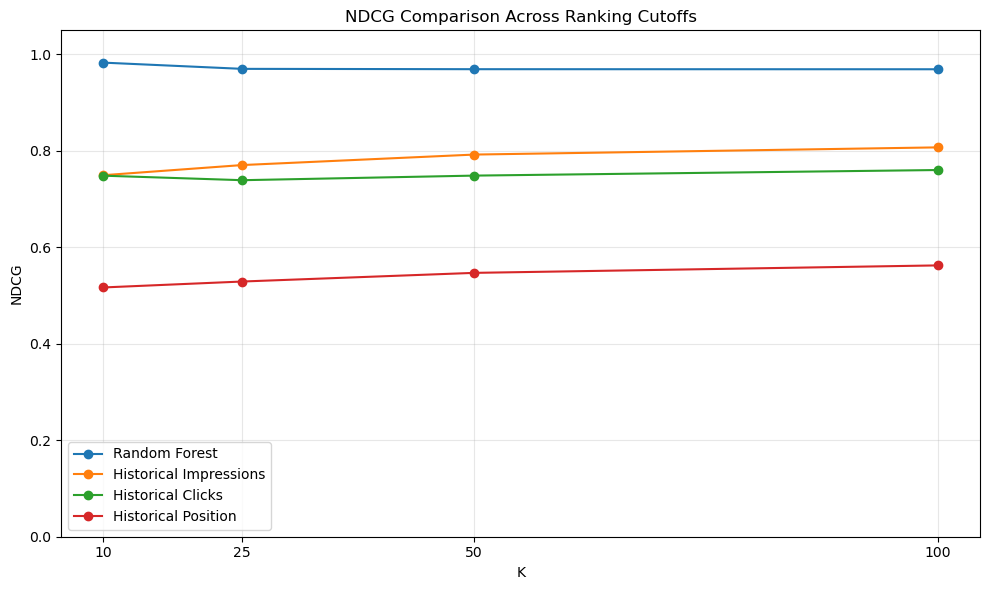

In [2]:
k_values = [10, 25, 50, 100]

model_ndcg = [0.983057, 0.970115, 0.969419, 0.969281]

impressions_ndcg = [0.749582, 0.770668, 0.792397, 0.807323]

clicks_ndcg = [0.748636, 0.739255, 0.748774, 0.760355]

position_ndcg = [0.516845, 0.529164, 0.547108, 0.562596]

plt.figure(figsize=(10, 6))

plt.plot(k_values, model_ndcg, marker='o', label='Random Forest')

plt.plot(k_values, impressions_ndcg, marker='o', label='Historical Impressions')

plt.plot(k_values, clicks_ndcg, marker='o', label='Historical Clicks')

plt.plot(k_values, position_ndcg, marker='o', label='Historical Position')

plt.title('NDCG Comparison Across Ranking Cutoffs')

plt.xlabel('K')

plt.ylabel('NDCG')

plt.xticks(k_values)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### 3.2 Baseline Comparison

|   K | Model NDCG | Impressions NDCG | Clicks NDCG | Position NDCG |
| --: | ---------: | ---------------: | ----------: | ------------: |
|  10 |     0.9831 |           0.7496 |      0.7486 |        0.5168 |
|  25 |     0.9701 |           0.7707 |      0.7393 |        0.5292 |
|  50 |     0.9694 |           0.7924 |      0.7488 |        0.5471 |
| 100 |     0.9693 |           0.8073 |      0.7604 |        0.5626 |


### 3.3 Feature Importance

| Feature                        | Importance |
| ------------------------------ | ---------: |
| historical_mean_position       |     0.6778 |
| historical_impressions_per_day |     0.1620 |
| historical_impressions         |     0.0857 |
| word_count                     |     0.0149 |
| char_count                     |     0.0148 |
| historical_ctr                 |     0.0113 |
| search_volume                  |     0.0073 |
| competition                    |     0.0056 |
| category_count                 |     0.0044 |
| backlinks                      |     0.0038 |
| cpc                            |     0.0031 |
| main_intent                    |     0.0025 |
| historical_reporting_days      |     0.0023 |
| historical_clicks_per_day      |     0.0021 |
| historical_clicks              |     0.0017 |
| competition_level              |     0.0006 |
| content_type                   |    0.00003 |


### Top Model Feature Importances

The feature importance analysis shows which input variables contributed most to the Random Forest ranking predictions. Historical mean position and historical impressions per day account for the largest share of the model's feature importance, while content-level characteristics contribute smaller shares.


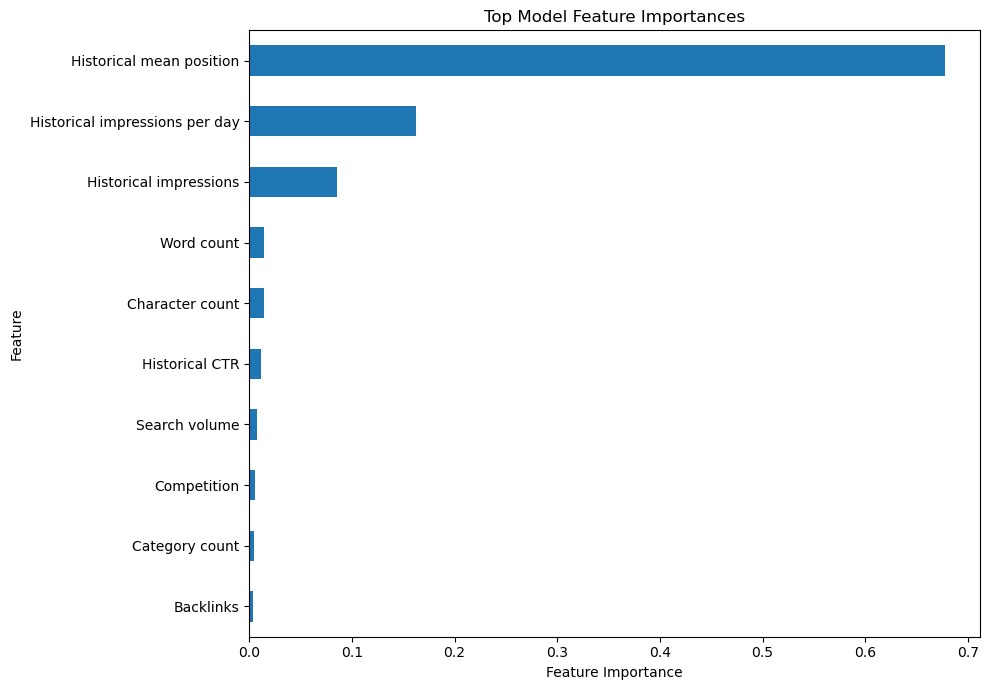

In [3]:
feature_importance = pd.Series({
    'Historical mean position': 0.677796,
    'Historical impressions per day': 0.161989,
    'Historical impressions': 0.085737,
    'Word count': 0.014936,
    'Character count': 0.014812,
    'Historical CTR': 0.011334,
    'Search volume': 0.007251,
    'Competition': 0.005609,
    'Category count': 0.004424,
    'Backlinks': 0.003817
}).sort_values(ascending=True)

plt.figure(figsize=(10, 7))

feature_importance.plot(kind='barh')

plt.title('Top Model Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## 3.4 Interpretation

The results suggest that a multi-signal model can distinguish between content items with different levels of relative opportunity more effectively than the individual historical-performance baselines evaluated in this study.

The ranking patterns also provide a practical interpretation of the model outputs. High-priority items frequently combine meaningful historical search visibility with weaker historical search positions and low CTR. In some cases, high search volume provides additional context for prioritization.

However, these patterns should be interpreted as signals for review rather than as evidence that a specific content change will produce a particular future outcome.

The model therefore functions primarily as a prioritization mechanism: it helps identify which content items may deserve attention first, while the final decision about whether and how to modify an item remains a human content or SEO decision.

# 4. Limitations

## 4.1 Constructed Opportunity Benchmark

The study does not contain a direct ground-truth label indicating whether a content optimization was successful. Therefore, the future opportunity score was constructed from observed future impressions, position, and CTR.

The benchmark measures relative opportunity according to these observed signals. It does not directly measure whether an optimization action would produce a successful outcome.

## 4.2 Observational Data

The analysis is based on observational search-performance and content data. The study does not control which content was optimized, when changes were made, or what other external factors affected performance.

Therefore, the observed relationships cannot be interpreted as causal effects.

## 4.3 Temporal Evaluation Limitation

The analysis separates the historical feature period from the subsequent evaluation period, which reduces direct use of future information during feature construction. However, the supervised model evaluation itself uses a random 80/20 train-test split within the modeling dataset.

A future study could use a larger number of rolling temporal validation windows to evaluate ranking stability across multiple time periods.

## 4.4 Data Availability and Missing Values

Several content-level variables contain missing values, including search volume, intent, word count, character count, backlinks, and optimization-related dates.

The modeling pipeline handles missing values through imputation, but missingness may still contain information about the underlying data-generation process.

## 4.5 Model Interpretation

Random Forest feature importance describes the relative contribution of features to the fitted model's predictions. It does not establish that changing a feature would directly change future search performance.

The reason codes used in the final recommendations are rule-based summaries of observed signals. They are designed to make recommendations understandable and actionable, but they are not direct explanations of the internal decision process of the Random Forest.

## 4.6 Generalization

The analysis is based on the available FlyRank dataset and its specific time period and content population. The results should therefore not automatically be generalized to other websites, industries, search environments, or future periods without additional validation.

## 4.7 Decision-Support Scope

The final ranking is intended to support human prioritization of content review. It does not replace expert judgment and does not guarantee improvements in Google rankings, organic traffic, CTR, or other future outcomes.

# 5. Ranked Recommendations

The final ranking is designed to help content teams prioritize items for review based on their predicted opportunity score and supporting historical signals.

The recommendations should be interpreted as **decision-support signals**, not as guarantees of future ranking, traffic, or CTR improvement.

### 5.1 Top-Ranked Content Opportunities

| Rank | Predicted Opportunity Score | Historical Impressions | Historical Mean Position | Historical CTR | Search Volume | Main Reason                                |
| ---: | --------------------------: | ---------------------: | -----------------------: | -------------: | ------------: | ------------------------------------------ |
|    1 |                      0.8186 |                  8,134 |                    87.96 |         0.0000 |            10 | High impressions + weak position + low CTR |
|    2 |                      0.7920 |                  9,870 |                    52.87 |         0.0004 |            40 | High impressions + weak position + low CTR |
|    3 |                      0.7872 |                 43,581 |                    24.01 |         0.0017 |             0 | High impressions + weak position + low CTR |
|    4 |                      0.7862 |                 33,557 |                    38.21 |         0.0011 |             0 | High impressions + weak position + low CTR |
|    5 |                      0.7770 |                  2,948 |                    60.10 |         0.0000 |         2,400 | High search volume + weak position         |
|    6 |                      0.7765 |                 74,617 |                    22.38 |         0.0001 |             0 | High impressions + weak position + low CTR |
|    7 |                      0.7756 |                 67,740 |                    23.75 |         0.0000 |            40 | High impressions + weak position + low CTR |
|    8 |                      0.7753 |                  7,809 |                    50.82 |         0.0013 |             0 | High impressions + weak position + low CTR |
|    9 |                      0.7722 |                  2,205 |                    60.31 |         0.0000 |         9,900 | High search volume + weak position         |
|   10 |                      0.7707 |                 22,813 |                    22.21 |         0.0013 |             0 | High impressions + weak position + low CTR |

### 5.2 Recommendation Categories
The ranked content items are grouped into reason categories based on their historical search-performance signals. The largest category consists of items with low CTR despite having search visibility, followed by items with multiple moderate opportunity signals and items with high search volume combined with weak position.


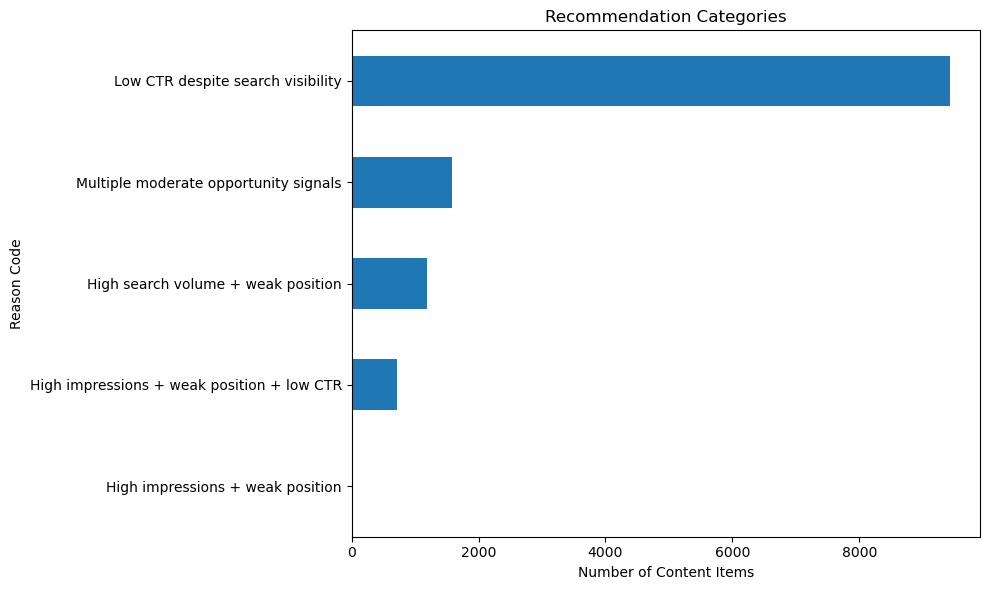

In [4]:
reason_counts = pd.Series({
    'Low CTR despite search visibility': 9427,
    'Multiple moderate opportunity signals': 1583,
    'High search volume + weak position': 1195,
    'High impressions + weak position + low CTR': 724,
    'High impressions + weak position': 24
}).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

reason_counts.plot(kind='barh')

plt.title('Recommendation Categories')

plt.xlabel('Number of Content Items')

plt.ylabel('Reason Code')

plt.tight_layout()

plt.show()

### 5.3 Evidence-Based Action Framework

The recommended workflow is:

1. **Prioritize high-scoring content items.**
2. **Inspect the supporting historical signals** such as impressions, average position, CTR, and search volume.
3. **Review the content and search intent** associated with the identified opportunity.
4. **Determine whether an optimization or content update is appropriate.**
5. **Monitor subsequent performance after any changes.**
6. **Use observed outcomes to improve future prioritization approaches.**

The model does not determine which content should definitely be changed. Instead, it identifies content items that may deserve closer human review based on observable evidence.

### 5.4 Decision-Support Interpretation

The ranking should therefore be interpreted as:

> **A prioritization mechanism for deciding which content items deserve review first, based on historical evidence and predicted relative opportunity.**

It should not be interpreted as a prediction that updating a specific content item will directly increase Google rankings, traffic, or click-through rate.

# 6. Reproducibility and Data Credit

### 6.1 Reproducibility

The analysis was developed as a sequence of documented Jupyter notebooks covering the complete workflow from dataset access to final opportunity ranking.

The workflow includes:

1. Dataset access and schema inspection.
2. Dataset inventory and relationship analysis.
3. Data-quality assessment.
4. Research-direction definition.
5. Analytical dataset construction.
6. Exploratory data analysis.
7. Machine-learning problem definition.
8. Feature engineering.
9. Baseline construction.
10. Machine-learning modeling.
11. Model interpretation.
12. Result interpretation.
13. Opportunity ranking.
14. Research-paper documentation.

Each stage is separated into a dedicated notebook to make the analysis easier to inspect, reproduce, and extend.

### 6.2 Project Repository

The complete project is maintained in the following repository:

**GitHub Repository:**
https://github.com/AnasMoShams/FlyRank-ML-Capstone

The repository contains the analysis notebooks, project documentation, and supporting implementation used throughout the workflow.

### 6.3 Dataset Credit

This project uses the **FlyRank Internship Warehouse** dataset provided through FlyRank.

The analysis uses the following dataset components:

* `dim_clients.parquet`
* `dim_content.parquet`
* `fact_content_daily_performance_sample.parquet`

The dataset was used for educational and analytical purposes within the internship project.

### 6.4 Analytical Workflow

The complete workflow follows this sequence:

**Raw Data → Data Quality → Analytical Dataset → EDA → Problem Definition → Feature Engineering → Baselines → Modeling → Evaluation → Interpretation → Opportunity Ranking → Recommendations**

This structure separates data preparation, modeling, evaluation, and interpretation, reducing the risk of mixing exploratory analysis with final model results.

### 6.5 Reproducibility Considerations

The modeling process uses fixed configuration values, including:

* Random seed: `42`
* Random Forest estimators: `200`
* Maximum tree depth: `12`
* Minimum samples per leaf: `5`

The preprocessing pipeline also performs numerical imputation and categorical encoding consistently between training and testing data.

Future extensions can replace the constructed opportunity benchmark with a directly observed optimization-success outcome when such labels become available.

### 6.6 Project Credit

**Project:** FlyRank ML Capstone
**Research Topic:** Content Opportunity Scoring
**Primary Research Question:** Can historical search performance and content-level characteristics be used to rank content items by their priority for review or improvement?

**Author:** Anas Mohamed Shams

### 6.7 Reproducibility Self-Check

* [x] Dataset sources are documented.
* [x] The analytical workflow is documented.
* [x] Modeling configuration is documented.
* [x] Random seed is documented.
* [x] Repository location is provided.
* [x] Dataset credit is included.
* [x] The project scope and research question are documented.


# 7. Final Review and Quality Check

### 7.1 Research Question Consistency

**Research Question:**

> Can historical search performance and content-level characteristics be used to rank content items by their priority for review or improvement?

The methodology, modeling process, evaluation metrics, and final recommendations are all aligned with this research question.

The project does not attempt to predict a guaranteed future Google ranking or directly estimate the causal effect of content optimization.

### 7.2 Methodology Consistency

The analysis follows a consistent workflow:

* Historical search-performance data is used to construct model features.
* Content-level characteristics are added as explanatory features.
* Future-period performance is used only to construct the evaluation benchmark.
* The future opportunity score is not used as an input feature.
* Preprocessing is fitted on the training data before being applied to the test data.
* Simple historical-performance baselines are evaluated using the same ranking metrics.
* The final output is a ranked list of content opportunities.

### 7.3 Evaluation Consistency

The model was evaluated using:

* Precision@10
* Precision@25
* Precision@50
* Precision@100
* Recall@10
* Recall@25
* Recall@50
* Recall@100
* NDCG@10
* NDCG@25
* NDCG@50
* NDCG@100

The model achieved NDCG values above 0.96 across all evaluated cutoffs.

The strongest NDCG result was obtained at K=10:

**NDCG@10 = 0.9831**

At K=100:

**NDCG@100 = 0.9693**

These values indicate strong alignment with the constructed future opportunity benchmark.

However, they should not be interpreted as evidence that the model can guarantee successful SEO optimization.

### 7.4 Baseline Consistency

The model was compared against three simple historical-performance ranking strategies:

1. Historical impressions.
2. Historical clicks.
3. Historical average position.

At K=100:

| Method                 | NDCG@100 |
| ---------------------- | -------: |
| Random Forest model    |   0.9693 |
| Historical impressions |   0.8073 |
| Historical clicks      |   0.7604 |
| Historical position    |   0.5626 |

The model showed stronger alignment with the constructed future opportunity benchmark than each tested baseline.

This comparison demonstrates the value of combining multiple historical and content-level signals within the tested experimental setup.

### 7.5 Feature Interpretation Consistency

The most influential model features were:

| Feature                        | Importance |
| ------------------------------ | ---------: |
| Historical mean position       |     0.6778 |
| Historical impressions per day |     0.1620 |
| Historical impressions         |     0.0857 |
| Word count                     |     0.0149 |
| Character count                |     0.0148 |
| Historical CTR                 |     0.0113 |
| Search volume                  |     0.0073 |

Historical mean position was the dominant feature according to Random Forest feature importance.

These values describe how the model used the available features for prediction. They should not be interpreted as causal effects.

### 7.6 Recommendation Consistency

The final ranking translates model predictions into practical review categories.

The main recommendation categories were:

* Low CTR despite search visibility.
* High search volume + weak position.
* High impressions + weak position + low CTR.
* High impressions + weak position.
* Multiple moderate opportunity signals.

Each category has an associated review action based on the observed signals.

The recommendations are intended to support human review rather than automatically determine which content must be changed.

### 7.7 Leakage Review

The final analysis was checked for the following potential leakage sources:

* [x] Future performance was excluded from model input features.
* [x] Future opportunity score was used only as the target.
* [x] Client and content identifiers were not used as predictive numerical features.
* [x] Post-outcome optimization information was not used as a feature.
* [x] Preprocessing was fitted using training data before transforming the test data.
* [x] No artificial optimization-success label was created.

### 7.8 Limitation Review

The following limitations remain important:

1. The future opportunity score is a constructed benchmark rather than a directly observed optimization-success label.
2. The dataset is observational and does not establish causality.
3. The model evaluation uses a random 80/20 split within the future-eligible modeling dataset.
4. Missing values may contain meaningful information that is not fully captured by standard imputation.
5. Random Forest feature importance describes model behavior but does not establish causal effects.
6. The analysis is based on a specific dataset, time period, and content population, which limits generalization to other environments.
7. The final ranking is intended as a decision-support mechanism rather than a guarantee of future SEO improvement.


# 8. Final Results Summary

This study developed a data-driven framework for prioritizing content items for review or potential improvement.

The analysis combined historical search-performance signals with content-level characteristics and used a Random Forest regression model to estimate a continuous opportunity score.

The model achieved:

* **NDCG@10:** 0.9831
* **NDCG@25:** 0.9701
* **NDCG@50:** 0.9694
* **NDCG@100:** 0.9693

The model consistently outperformed the tested historical-impressions, historical-clicks, and historical-position baselines in terms of NDCG within the evaluation setup.

The most influential model signal was historical mean position, followed by historical impressions per day and historical impressions.

The final ranking converts these predictions into actionable review categories, allowing content teams to focus attention on items showing combinations of search visibility, weak position, low CTR, or higher search demand.

The framework should be considered a **decision-support system** rather than a causal SEO optimization model. The constructed future opportunity score provides a benchmark for relative prioritization, but it does not represent confirmed optimization success.

Future work could improve the framework by incorporating directly observed optimization outcomes, longer historical periods, rolling temporal validation, additional content-quality features, and post-optimization performance measurements.
